In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras import datasets
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras import layers, models
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.utils import to_categorical

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import accuracy_score




In [ ]:
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']

In [ ]:
from google.colab import files

def save_plot(filename):
    path = f"{filename}.eps"
    plt.savefig(path, format='eps', dpi=600, bbox_inches='tight')
    files.download(path)
    print(f"Saved and downloaded: {path}")


In [ ]:
(x_train, y_train), (x_test, y_test) = datasets.cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1763s 10us/step


In [ ]:
class_names=['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

print("Train shape:", x_train.shape, y_train.shape)
print("Test shape :", x_test.shape, y_test.shape)

Train shape: (50000, 32, 32, 3) (50000, 1)
Test shape : (10000, 32, 32, 3) (10000, 1)


In [ ]:
#Normalization
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saved and downloaded: plot1_class_distribution.eps


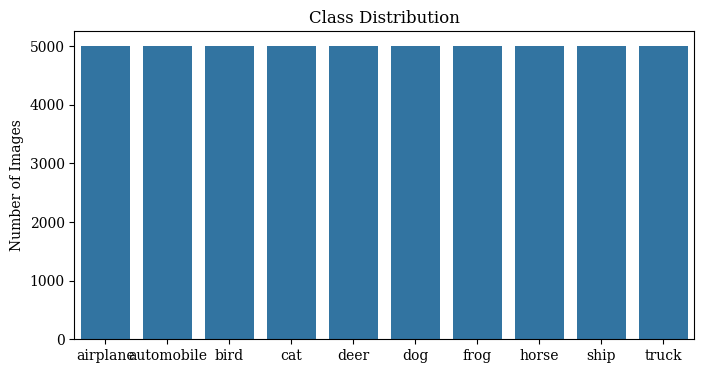

In [ ]:
#Class Distribution
plt.figure(figsize=(8,4))

unique, counts = np.unique(y_train, return_counts=True)

sns.barplot(x=class_names, y=counts)


plt.title("Class Distribution")
plt.ylabel("Number of Images")
save_plot("plot1_class_distribution")
plt.show()


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saved and downloaded: plot2_class_images.eps


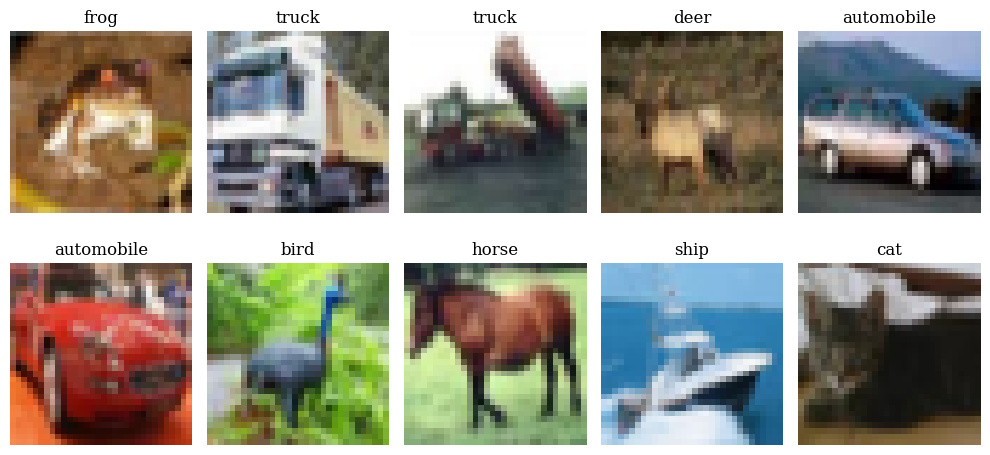

In [ ]:

plt.figure(figsize=(10,5))

for i in range(10):

    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")

plt.tight_layout()
save_plot("plot2_class_images")
plt.show()

In [ ]:
#CNN Model

model = Sequential()

model.add(Conv2D(32,(3,3),activation='relu',
                 input_shape=(32,32,3)))
model.add(MaxPooling2D())

model.add(Conv2D(64,(3,3),activation='relu'))
model.add(MaxPooling2D())

model.add(Conv2D(128,(3,3),activation='relu'))
model.add(MaxPooling2D())

model.add(Flatten())

model.add(Dense(128,activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(10,activation='softmax'))

model.summary()


model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


history = model.fit(
    x_train,
    y_train_cat,
    epochs=20,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 160,202 (625.79 KB)

 Trainable params: 160,202 (625.79 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.3498 - loss: 1.7566 - val_accuracy: 0.4937 - val_loss: 1.4072
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.4973 - loss: 1.3892 - val_accuracy: 0.5590 - val_loss: 1.2420
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5554 - loss: 1.2479 - val_accuracy: 0.6080 - val_loss: 1.1189
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5991 - loss: 1.1346 - val_accuracy: 0.6308 - val_loss: 1.0544
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6329 - loss: 1.0468 - val_accuracy: 0.6599 - val_loss: 0.9740
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6596 - loss: 0.9755 - val_accuracy: 0.6747 - val_loss: 0.9288
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6779 - loss: 0.9213 - val_accuracy: 0.6798 - val_loss: 0.9103
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6977 - loss: 0.8615 - val_accuracy: 0

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saved and downloaded: plot3_accuracy.eps


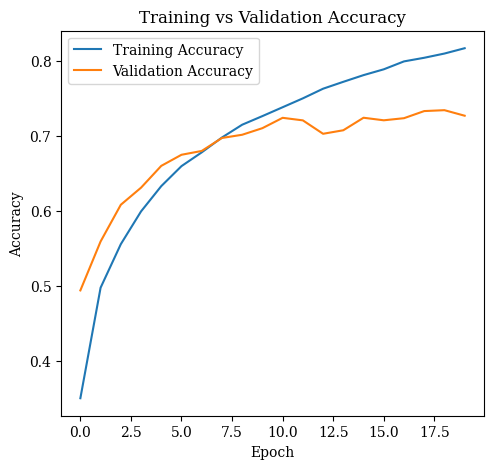

In [ ]:
#Accuracy Plots

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)

plt.plot(history.history['accuracy'],label='Training Accuracy')
plt.plot(history.history['val_accuracy'],label='Validation Accuracy')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
save_plot("plot3_accuracy")
plt.show()

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saved and downloaded: plot4_loss.eps


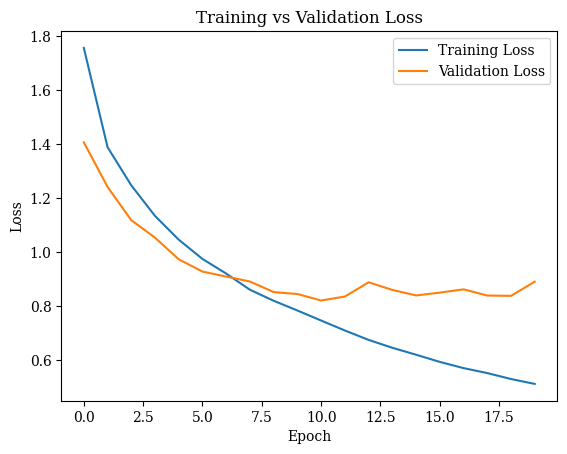

In [ ]:
#Loss plots


plt.plot(history.history['loss'],label='Training Loss')
plt.plot(history.history['val_loss'],label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
save_plot("plot4_loss")
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7242 - loss: 0.8905

Test Accuracy : 0.7242000102996826
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

Accuracy : 0.7242
Precision : 0.7270026512639404
Recall : 0.7242
F1 Score : 0.7228627548182888

Classification Report

              precision    recall  f1-score   support

    airplane       0.70      0.82      0.76      1000
  automobile       0.87      0.82      0.85      1000
        bird       0.61      0.62      0.61      1000
         cat       0.57      0.54      0.56      1000
        deer       0.70      0.63      0.66      1000
         dog       0.67      0.61      0.64      1000
        frog       0.72      0.86      0.78      1000
       horse       0.74      0.77      0.76      1000
        ship       0.89      0.72      0.80      1000
       truck       0.78      0.85      0.81      1000

    accuracy                           0.72     10000
   macro avg       0.73      0.72      0.72     10000
weighted avg       0.73 

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saved and downloaded: plot5_confusion_matrix.eps


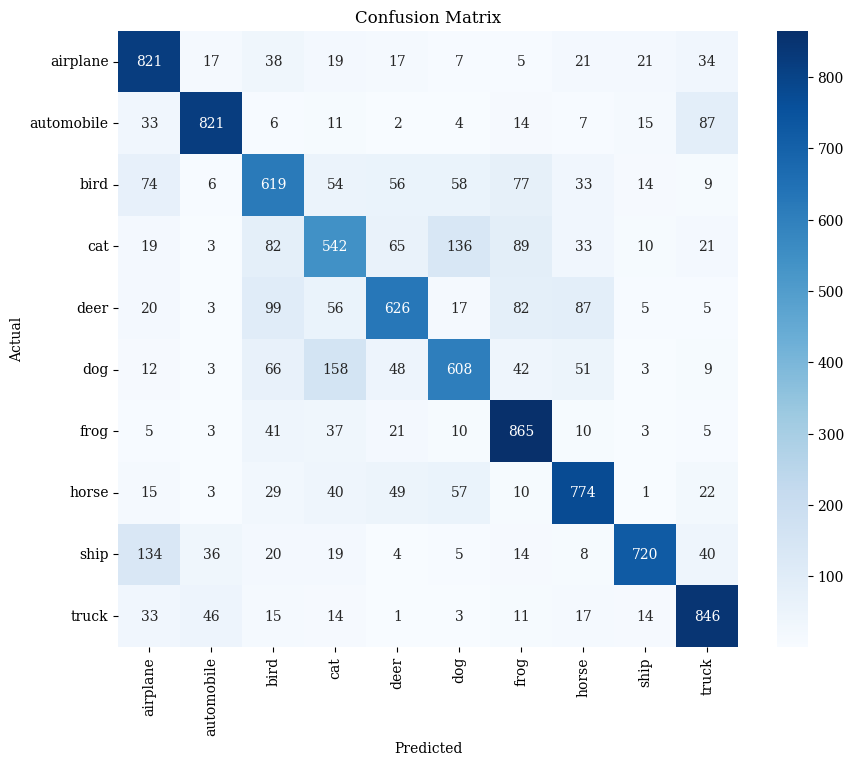

In [ ]:
#Model Evaluation


loss, accuracy = model.evaluate(x_test,y_test_cat)

print("\nTest Accuracy :",accuracy)

pred_prob = model.predict(x_test)

y_pred = np.argmax(pred_prob,axis=1)
y_true = y_test.flatten()



acc = accuracy_score(y_true,y_pred)
print("\nAccuracy :",acc)



precision = precision_score(y_true,y_pred,average='weighted')
print("Precision :",precision)

recall = recall_score(y_true,y_pred,average='weighted')
print("Recall :",recall)

f1 = f1_score(y_true,y_pred,average='weighted')
print("F1 Score :",f1)



print("\nClassification Report\n")
print(classification_report(y_true,y_pred,target_names=class_names))

cm = confusion_matrix(y_true,y_pred)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
save_plot("plot5_confusion_matrix")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 568ms/step


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saved and downloaded: plot6_feature_maps_conv_layer_1.eps


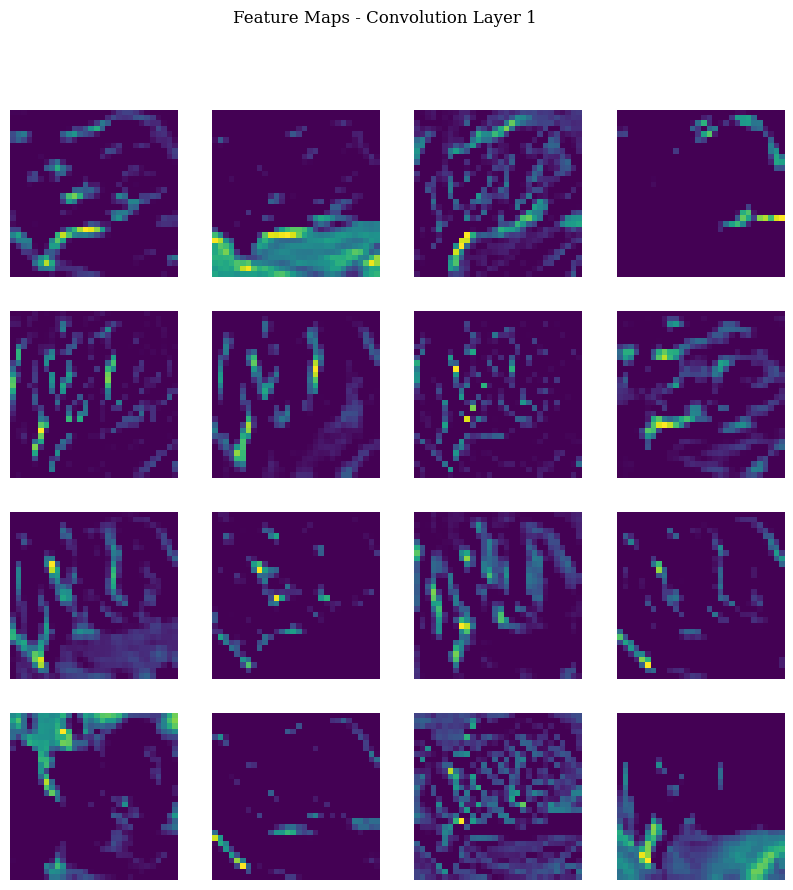

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saved and downloaded: plot6_feature_maps_conv_layer_2.eps


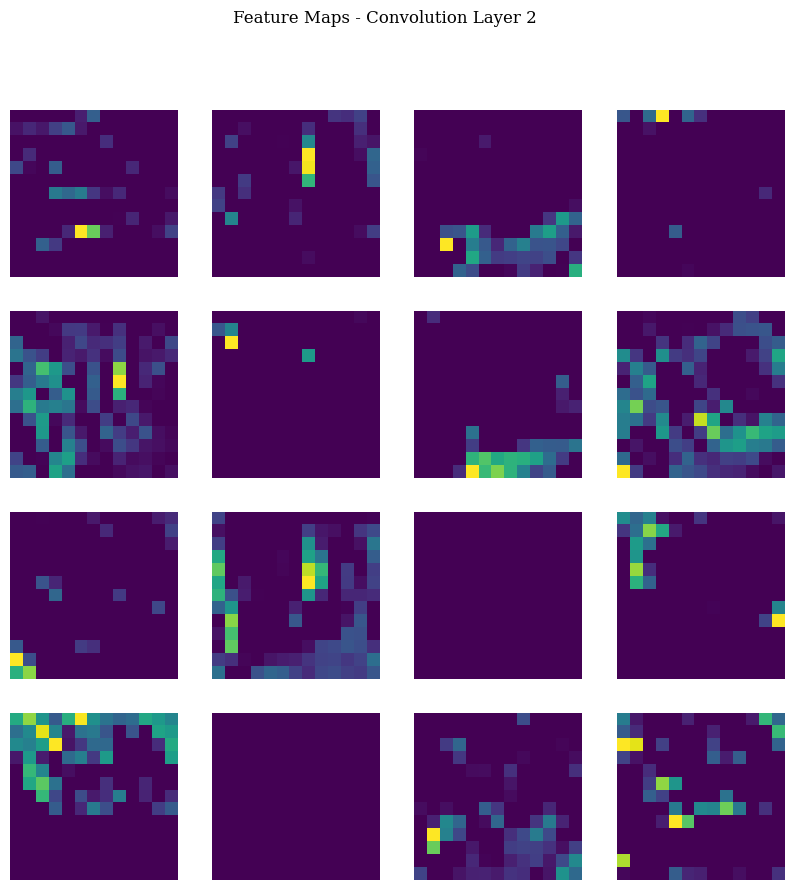

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saved and downloaded: plot6_feature_maps_conv_layer_3.eps


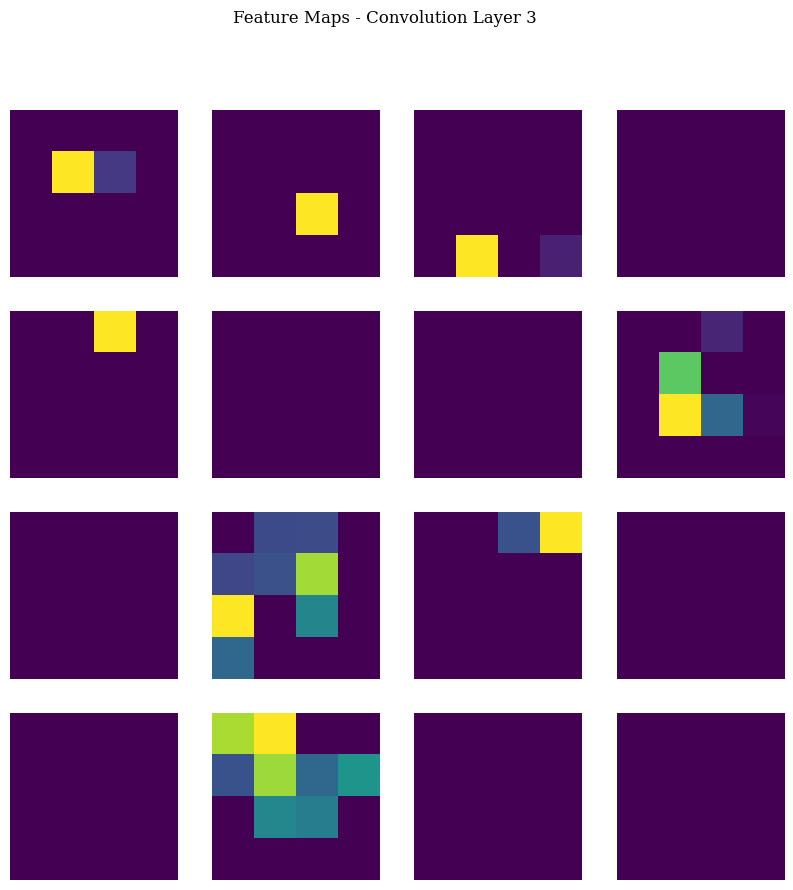

In [ ]:
import tensorflow as tf

#Feature Map

layer_outputs = [layer.output for layer in model.layers
                 if isinstance(layer, tf.keras.layers.Conv2D)]

activation_model = tf.keras.models.Model(
    inputs=model.layers[0].input, # Use the input of the first layer
    outputs=layer_outputs
)

sample = np.expand_dims(x_test[0],axis=0)

feature_maps = activation_model.predict(sample)

for layer_num, fmap in enumerate(feature_maps):

    plt.figure(figsize=(10,10))

    n_features = min(16, fmap.shape[-1])

    for i in range(n_features):

        plt.subplot(4,4,i+1)
        plt.imshow(fmap[0,:,:,i], cmap='viridis')
        plt.axis('off')

    plt.suptitle(f"Feature Maps - Convolution Layer {layer_num+1}")
    save_plot(f"plot6_feature_maps_conv_layer_{layer_num+1}")
    plt.show()